NETFLIX DATASET ANALYSIS

Name: Veronica James Okuba

In [3]:
from IPython.core.debugger import Pdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files

uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [6]:
import pandas as pd

# Load dataset
df = pd.read_csv('netflix_titles.csv')

# First 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.shape

(8807, 12)

In [8]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
df.select_dtypes(include=['int64','float64']).columns

Index(['release_year'], dtype='object')

In [11]:
df.select_dtypes(include=['object']).columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [12]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [13]:
df['director']= df['director'].fillna('unknown')

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df=df.drop_duplicates()

In [16]:
df.columns=df.columns.str.strip().str.lower().str.replace("","_")

In [19]:
df['_t_y_p_e_']=df['_t_y_p_e_'].str.upper()

In [27]:
df['_d_a_t_e___a_d_d_e_d_'] = pd.to_datetime(df['_d_a_t_e___a_d_d_e_d_'], format='%B %d, %Y', errors='coerce')

In [28]:
df.describe()

,_d_a_t_e___a_d_d_e_d_,_r_e_l_e_a_s_e___y_e_a_r_
count,8797,8807.000000
mean,2019-05-17 05:59:08.436967168,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-02 00:00:00,2017.000000
75%,2020-08-19 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


In [29]:
df.head()

,_s_h_o_w___i_d_,_t_y_p_e_,_t_i_t_l_e_,_d_i_r_e_c_t_o_r_,_c_a_s_t_,_c_o_u_n_t_r_y_,_d_a_t_e___a_d_d_e_d_,_r_e_l_e_a_s_e___y_e_a_r_,_r_a_t_i_n_g_,_d_u_r_a_t_i_o_n_,_l_i_s_t_e_d___i_n_,_d_e_s_c_r_i_p_t_i_o_n_
0,s1,MOVIE,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV SHOW,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV SHOW,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV SHOW,Jailbirds New Orleans,unknown,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV SHOW,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [30]:
df.dtypes

,0
_s_h_o_w___i_d_,object
_t_y_p_e_,object
_t_i_t_l_e_,object
_d_i_r_e_c_t_o_r_,object
_c_a_s_t_,object
_c_o_u_n_t_r_y_,object
_d_a_t_e___a_d_d_e_d_,datetime64[ns]
_r_e_l_e_a_s_e___y_e_a_r_,int64
_r_a_t_i_n_g_,object
_d_u_r_a_t_i_o_n_,object


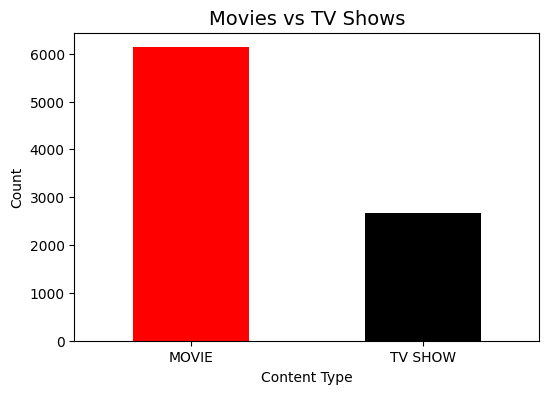

In [34]:
plt.figure(figsize=(6,4))
df['_t_y_p_e_'].value_counts().plot(
    kind='bar',
    color=['red', 'black']
)

plt.title('Movies vs TV Shows', color='black', fontsize=14)
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

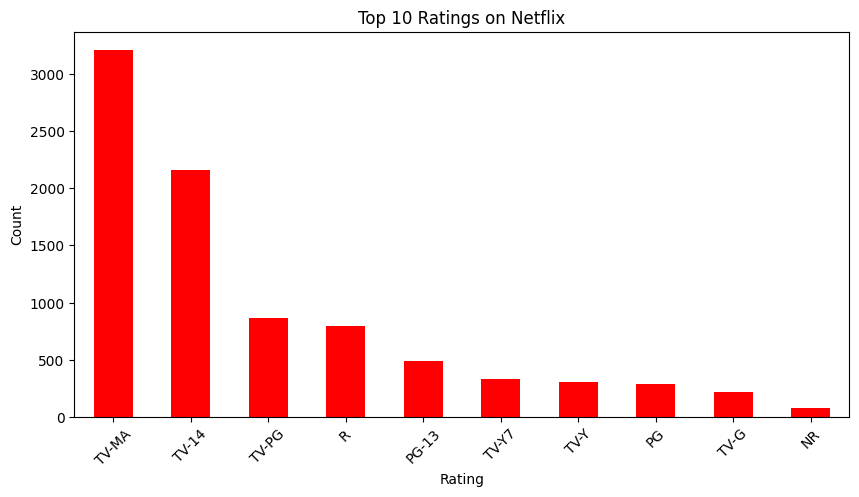

In [37]:
plt.figure(figsize=(10,5))
df['_r_a_t_i_n_g_'].value_counts().head(10).plot(
    kind='bar',
    color=['red']
)

plt.title('Top 10 Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

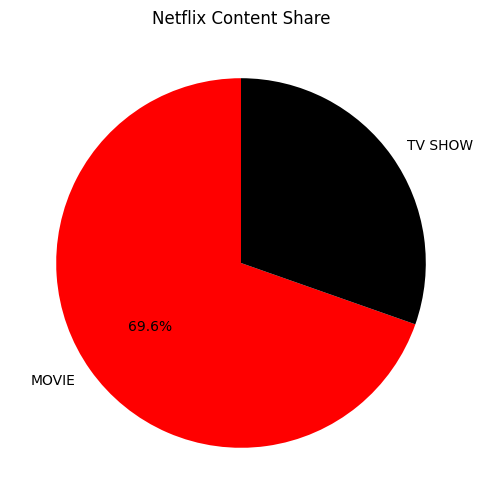

In [40]:
type_counts = df['_t_y_p_e_'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=['red', 'black'],
    startangle=90
)

plt.title('Netflix Content Share')
plt.show()

In [43]:
df['year_added'] = df['_d_a_t_e___a_d_d_e_d_'].dt.year

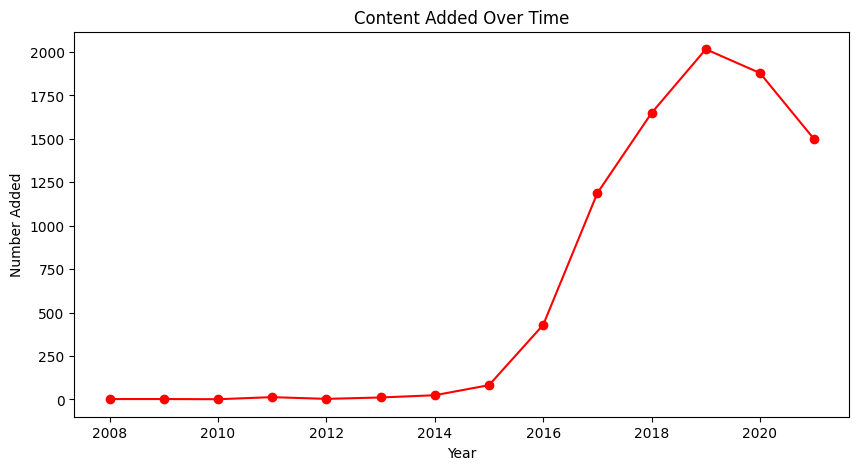

In [45]:
year_counts = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(
    year_counts.index,
    year_counts.values,
    marker='o',
    color='red'   # line color
)

plt.title('Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Number Added')
plt.show()

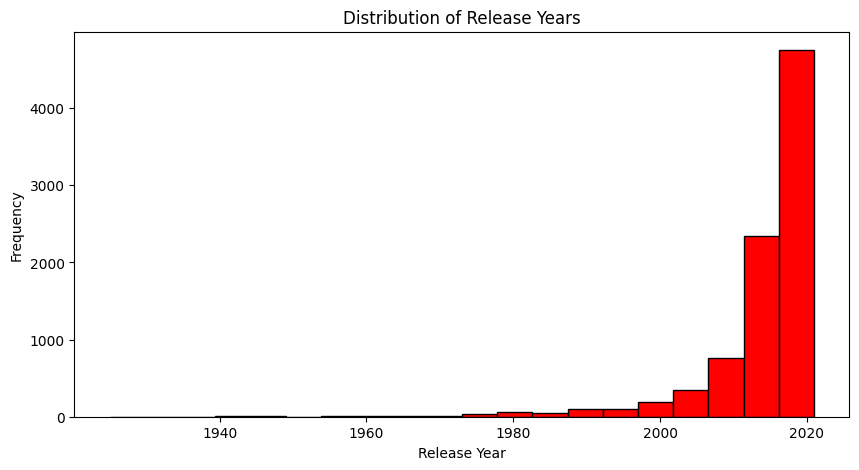

In [51]:
plt.figure(figsize=(10,5))
plt.hist(
    df['_r_e_l_e_a_s_e___y_e_a_r_'],
    bins=20,
    color='red',       # bar color
    edgecolor='black'  # border color
)

plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

In [52]:
df.to_csv('cleaned_netflix_titles.csv', index=False)

print("cleaned dataset saved as cleaned_netflix_titles.csv")

cleaned dataset saved as cleaned_netflix_titles.csv


In [53]:
from google.colab import files

files.download('cleaned_netflix_titles.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>